## Example notebook to use NRHybSur3dq8-gwNRHME model

NRHybSur3dq8-gwNRHME (multi-modal eccentric nonspinning model) = SEOBNRv5EHM (22 mode eccentric model) + NRHybSur3dq8 (multi-modal circular nonspinning model) + gwNRHME framework

In [1]:
import sys
# install gwModels in editable mode from the parent directory
!{sys.executable} -m pip install -e ../ --no-deps --quiet

import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import gwModels
gwModels.utils.set_rcparams()

lal.MSUN_SI != Msun


### 1. Generate waveforms by combining NRHybSur3dq8 (multi-mode) and SEOBNRv5EHM (22 mode)

In [2]:
# Set the binary parameters
params = {"q": 2.6,       # mass ratio
          "omega0": 0.02, # initial dimensionless orbital frequency
          "e0": 0.1,      # initial eccentricity
          "l0": 0}        # initial relativistic anomaly

In [3]:
# generate eccentric (2,2) mode using SEOBNRv5EHM
seob = gwModels.waveforms.genSEOBNRv5EHM()
tecc, hecc_dict = seob.generate_SEOBNRv5EHM(params)
hecc = hecc_dict['h_l2m2']

# generate circular higher modes using NRHybSur3dq8
gwsur = gwModels.waveforms.genNRHybSur3dq8()
tsur, hsur = gwsur.generate_NRHybSur3dq8(params)

# combine using gwNRHME framework
gwnrhme = gwModels.frameworks.NRHME(t_ecc=tecc,
                                     h_ecc_dict={'h_l2m2': hecc},
                                     t_cir=tsur,
                                     h_cir_dict=hsur)

tNRE = gwnrhme.t_common
hNRE = gwnrhme.hNRE

Loaded NRHybSur3dq8 model


In [4]:
# print available modes
print(hNRE.keys())

dict_keys(['h_l2m2', 'h_l2m1', 'h_l3m2', 'h_l4m4', 'h_l3m3', 'h_l3m1', 'h_l4m3', 'h_l4m2', 'h_l5m5'])


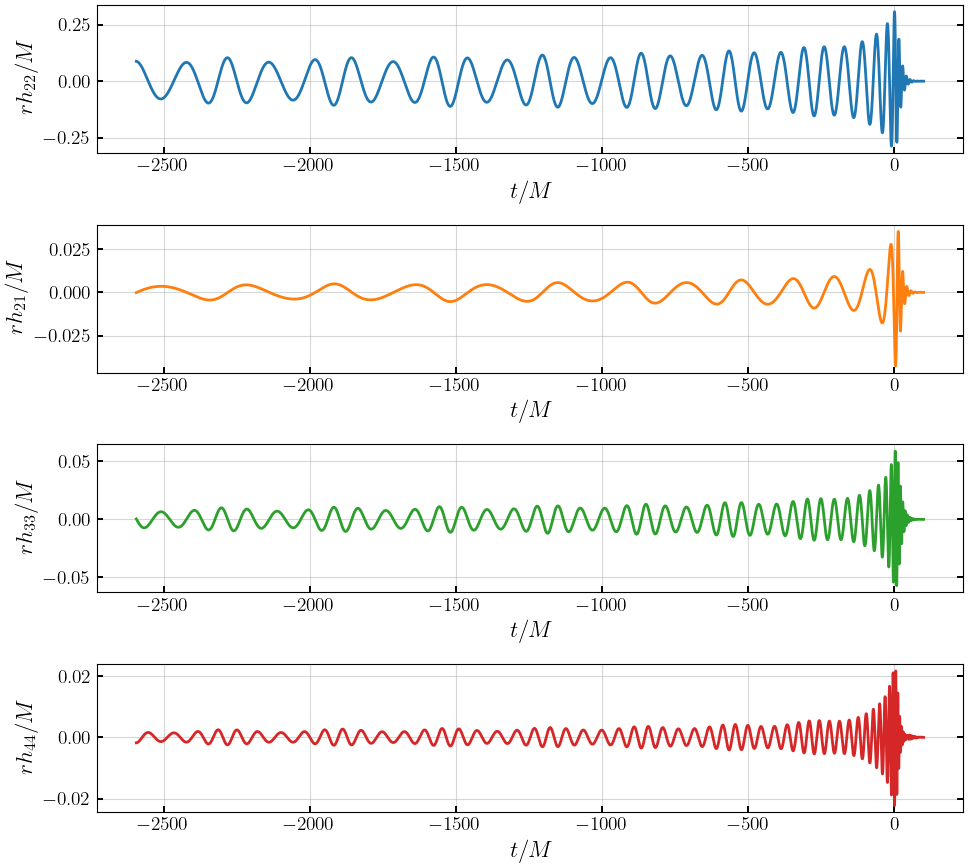

In [5]:
# plot waveform
plt.figure(figsize=(10,9))
plt.subplot(411)
plt.plot(tNRE, hNRE['h_l2m2'].real, '-', lw=2, color='C0', label='(2,2)')
plt.xlabel('$t/M$')
plt.ylabel('$rh_{22}/M$')
plt.subplot(412)
plt.plot(tNRE, hNRE['h_l2m1'].real, '-', lw=2, color='C1', label='(2,1)')
plt.xlabel('$t/M$')
plt.ylabel('$rh_{21}/M$')
plt.subplot(413)
plt.plot(tNRE, hNRE['h_l3m3'].real, '-', lw=2, color='C2', label='(3,3)')
plt.xlabel('$t/M$')
plt.ylabel('$rh_{33}/M$')
plt.subplot(414)
plt.plot(tNRE, hNRE['h_l4m4'].real, '-', lw=2, color='C3', label='(4,4)')
plt.xlabel('$t/M$')
plt.ylabel('$rh_{44}/M$')
plt.tight_layout()
plt.show()

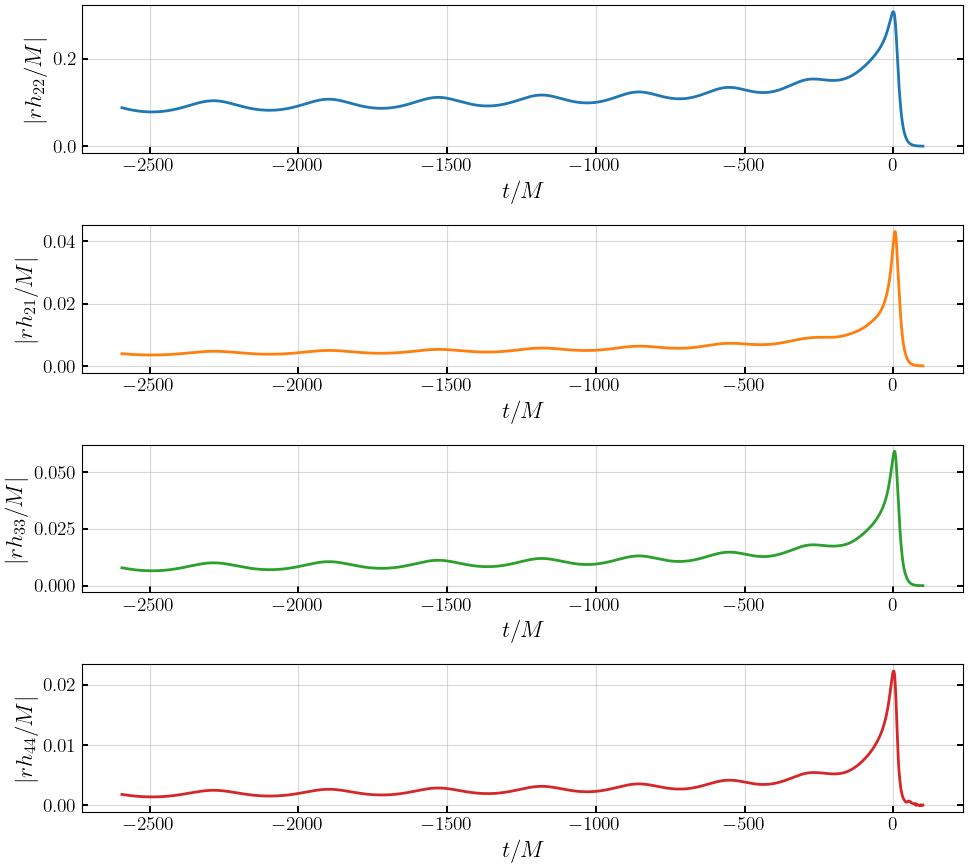

In [6]:
# plot amplitudes
plt.figure(figsize=(10,9))
plt.subplot(411)
plt.plot(tNRE, abs(hNRE['h_l2m2']), '-', lw=2, color='C0', label='(2,2)')
plt.xlabel('$t/M$')
plt.ylabel('$|rh_{22}/M|$')
plt.subplot(412)
plt.plot(tNRE, abs(hNRE['h_l2m1']), '-', lw=2, color='C1', label='(2,1)')
plt.xlabel('$t/M$')
plt.ylabel('$|rh_{21}/M|$')
plt.subplot(413)
plt.plot(tNRE, abs(hNRE['h_l3m3']), '-', lw=2, color='C2', label='(3,3)')
plt.xlabel('$t/M$')
plt.ylabel('$|rh_{33}/M|$')
plt.subplot(414)
plt.plot(tNRE, abs(hNRE['h_l4m4']), '-', lw=2, color='C3', label='(4,4)')
plt.xlabel('$t/M$')
plt.ylabel('$|rh_{44}/M|$')
plt.tight_layout()
plt.show()

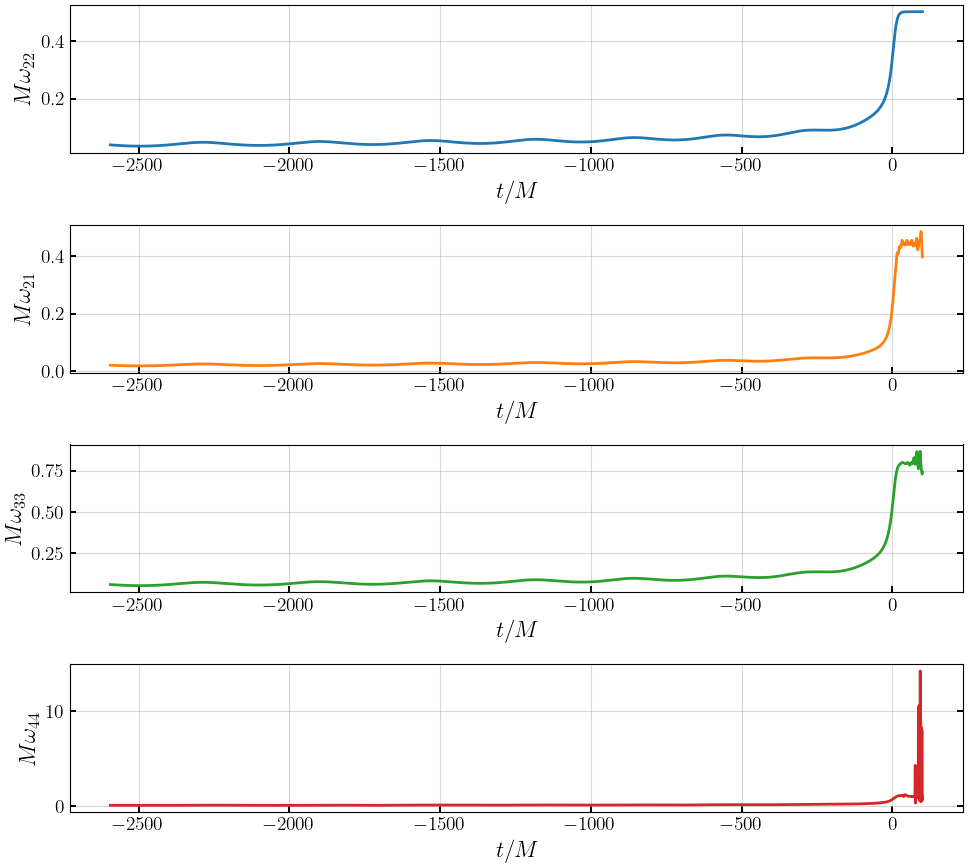

In [7]:
# plot frequencies
from gwModels.utils.features import get_frequency

plt.figure(figsize=(10,9))
plt.subplot(411)
plt.plot(tNRE, get_frequency(tNRE, hNRE['h_l2m2']), '-', lw=2, color='C0', label='(2,2)')
plt.xlabel('$t/M$')
plt.ylabel('$M\\omega_{22}$')
plt.subplot(412)
plt.plot(tNRE, get_frequency(tNRE, hNRE['h_l2m1']), '-', lw=2, color='C1', label='(2,1)')
plt.xlabel('$t/M$')
plt.ylabel('$M\\omega_{21}$')
plt.subplot(413)
plt.plot(tNRE, get_frequency(tNRE, hNRE['h_l3m3']), '-', lw=2, color='C2', label='(3,3)')
plt.xlabel('$t/M$')
plt.ylabel('$M\\omega_{33}$')
plt.subplot(414)
plt.plot(tNRE, get_frequency(tNRE, hNRE['h_l4m4']), '-', lw=2, color='C3', label='(4,4)')
plt.xlabel('$t/M$')
plt.ylabel('$M\\omega_{44}$')
plt.tight_layout()
plt.show()

### 2. Generate waveforms from combined model using NRHybSur3dq8_gwNRHME

This is a convenience wrapper that does all three steps (SEOBNRv5EHM + NRHybSur3dq8 + gwNRHME) in a single call.

In [8]:
# instantiate and generate waveform in one go
wf = gwModels.waveforms.NRHybSur3dq8_gwNRHME()
tNRE2, hNRE2 = wf.generate_waveform(params)
print(hNRE2.keys())

Loaded NRHybSur3dq8 model
dict_keys(['h_l2m2', 'h_l2m1', 'h_l3m2', 'h_l4m4', 'h_l3m3', 'h_l3m1', 'h_l4m3', 'h_l4m2', 'h_l5m5'])


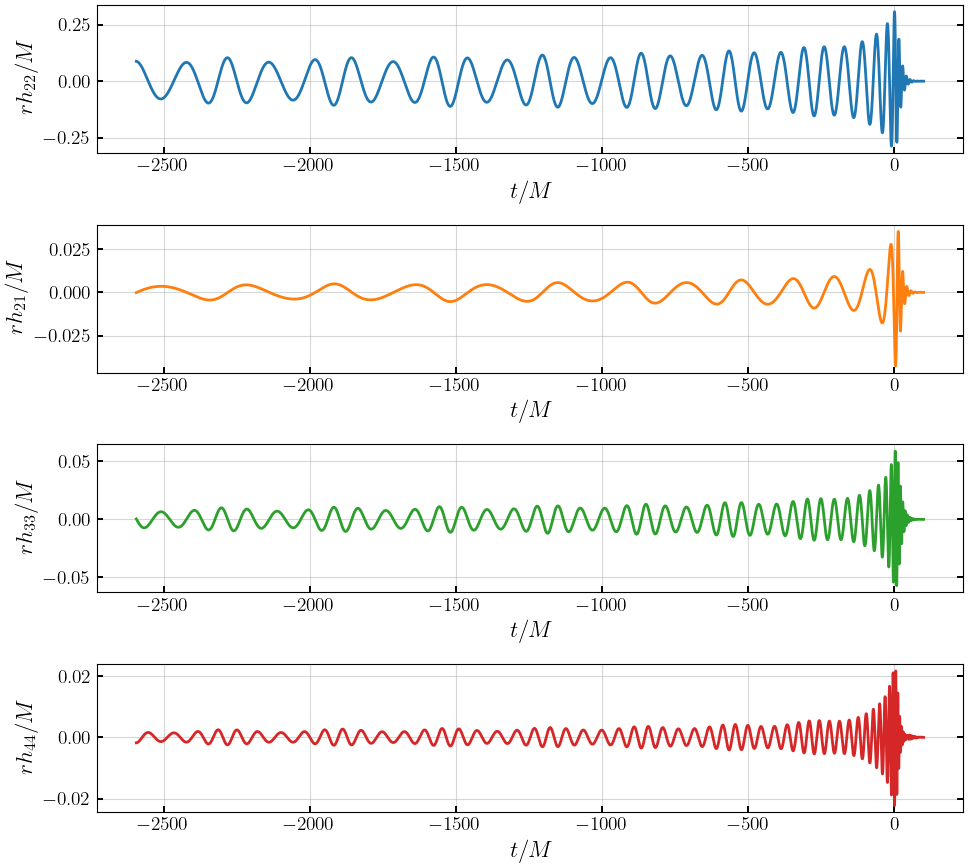

In [9]:
# plot waveform
plt.figure(figsize=(10,9))
plt.subplot(411)
plt.plot(tNRE2, hNRE2['h_l2m2'].real, '-', lw=2, color='C0', label='(2,2)')
plt.xlabel('$t/M$')
plt.ylabel('$rh_{22}/M$')
plt.subplot(412)
plt.plot(tNRE2, hNRE2['h_l2m1'].real, '-', lw=2, color='C1', label='(2,1)')
plt.xlabel('$t/M$')
plt.ylabel('$rh_{21}/M$')
plt.subplot(413)
plt.plot(tNRE2, hNRE2['h_l3m3'].real, '-', lw=2, color='C2', label='(3,3)')
plt.xlabel('$t/M$')
plt.ylabel('$rh_{33}/M$')
plt.subplot(414)
plt.plot(tNRE2, hNRE2['h_l4m4'].real, '-', lw=2, color='C3', label='(4,4)')
plt.xlabel('$t/M$')
plt.ylabel('$rh_{44}/M$')
plt.tight_layout()
plt.show()

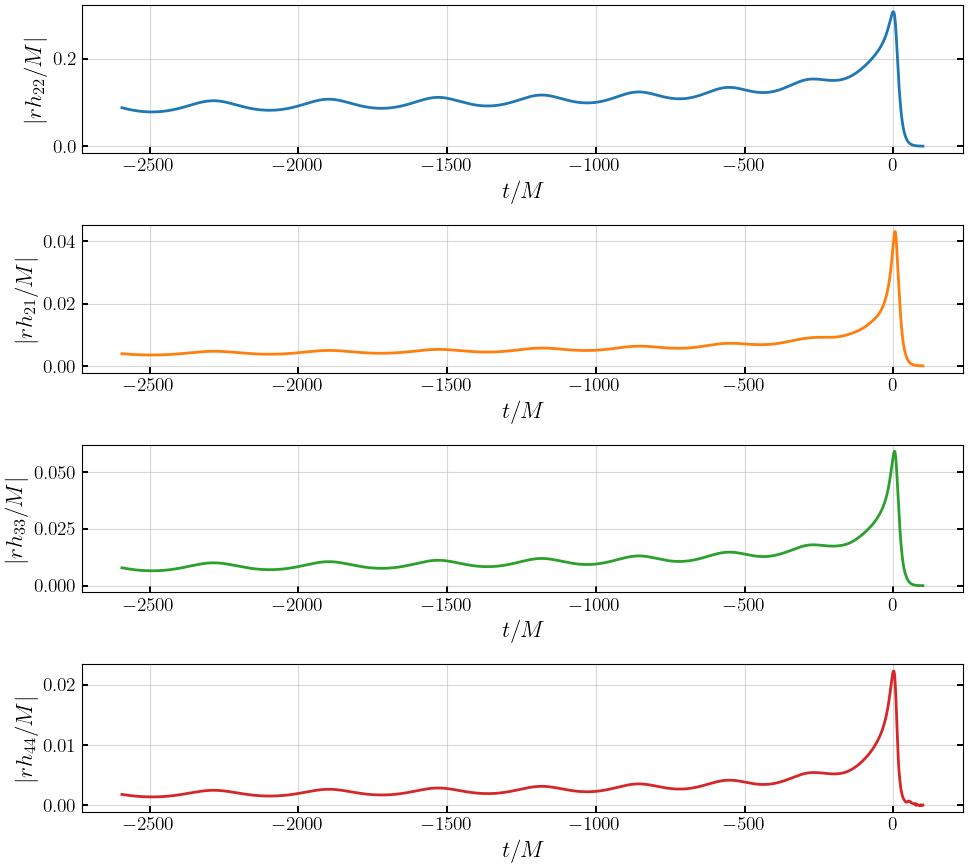

In [10]:
# plot amplitudes
plt.figure(figsize=(10,9))
plt.subplot(411)
plt.plot(tNRE2, abs(hNRE2['h_l2m2']), '-', lw=2, color='C0', label='(2,2)')
plt.xlabel('$t/M$')
plt.ylabel('$|rh_{22}/M|$')
plt.subplot(412)
plt.plot(tNRE2, abs(hNRE2['h_l2m1']), '-', lw=2, color='C1', label='(2,1)')
plt.xlabel('$t/M$')
plt.ylabel('$|rh_{21}/M|$')
plt.subplot(413)
plt.plot(tNRE2, abs(hNRE2['h_l3m3']), '-', lw=2, color='C2', label='(3,3)')
plt.xlabel('$t/M$')
plt.ylabel('$|rh_{33}/M|$')
plt.subplot(414)
plt.plot(tNRE2, abs(hNRE2['h_l4m4']), '-', lw=2, color='C3', label='(4,4)')
plt.xlabel('$t/M$')
plt.ylabel('$|rh_{44}/M|$')
plt.tight_layout()
plt.show()

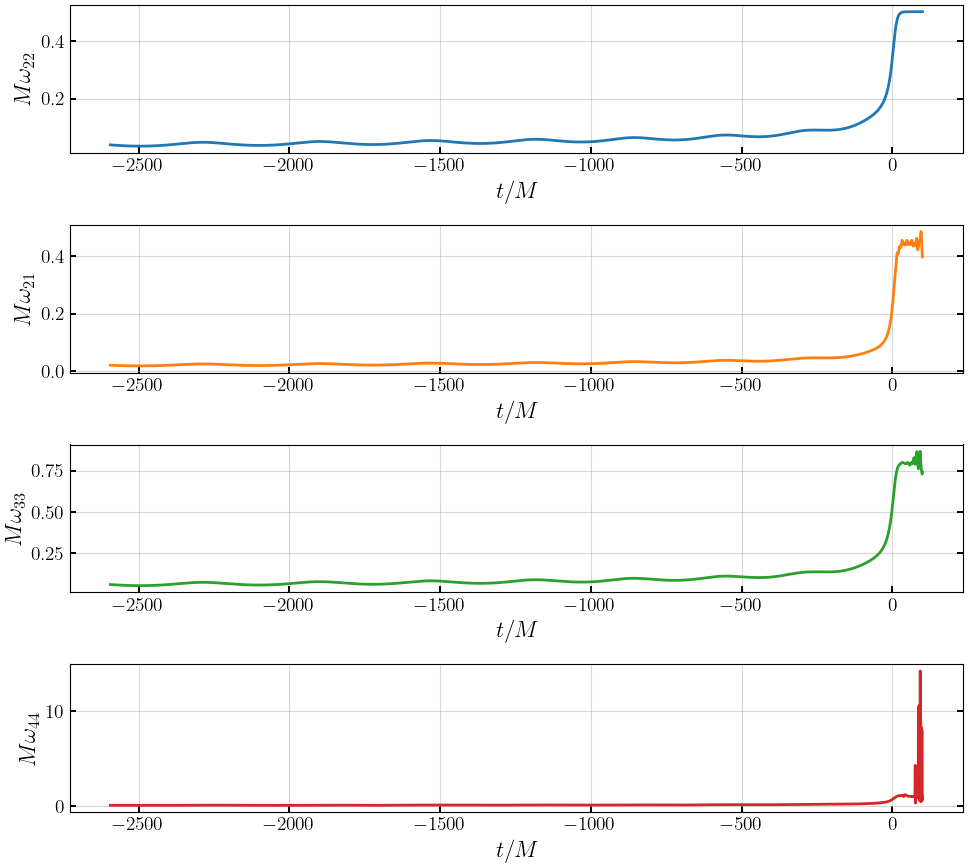

In [11]:
# plot frequencies
plt.figure(figsize=(10,9))
plt.subplot(411)
plt.plot(tNRE2, get_frequency(tNRE2, hNRE2['h_l2m2']), '-', lw=2, color='C0', label='(2,2)')
plt.xlabel('$t/M$')
plt.ylabel('$M\\omega_{22}$')
plt.subplot(412)
plt.plot(tNRE2, get_frequency(tNRE2, hNRE2['h_l2m1']), '-', lw=2, color='C1', label='(2,1)')
plt.xlabel('$t/M$')
plt.ylabel('$M\\omega_{21}$')
plt.subplot(413)
plt.plot(tNRE2, get_frequency(tNRE2, hNRE2['h_l3m3']), '-', lw=2, color='C2', label='(3,3)')
plt.xlabel('$t/M$')
plt.ylabel('$M\\omega_{33}$')
plt.subplot(414)
plt.plot(tNRE2, get_frequency(tNRE2, hNRE2['h_l4m4']), '-', lw=2, color='C3', label='(4,4)')
plt.xlabel('$t/M$')
plt.ylabel('$M\\omega_{44}$')
plt.tight_layout()
plt.show()